# Trực quan hóa dữ liệu và Thống kê tổng quan (EDA)
Sử dụng file dữ liệu đã làm sạch `Combined_Features_Cleaned.xlsx` để phân tích thống kê, đồ thị nhằm hiểu sâu hơn về độ rời rạc, phân phối và độ tương quan giữa 7 features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cài đặt style chung cho đồ thị đẹp mắt hơn
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# 1. Đọc dữ liệu
df = pd.read_excel('Combined_Features_Cleaned.xlsx')
display(df.head())

,Year,Bank_Name,Report_Score_X,News_Score_Y_mean,Delta_Gap,E_tfidf,S_tfidf,G_tfidf,GSI_Raw
0,2023,ACB,0.027297,0.014135,0.013161,0.026424,0.007108,0.017820,0.017117
1,2023,Agribank,0.010542,0.008809,0.001733,0.020279,0.005499,0.018529,0.014769
2,2023,BIDV,0.020037,0.005126,0.014911,0.017630,0.005169,0.013448,0.012082
3,2023,HDBank,0.015611,0.011085,0.004526,0.011537,0.003508,0.010396,0.008480
4,2023,LP Bank,0.015845,0.002266,0.013579,0.015782,0.004384,0.009912,0.010026


### 1. Thống kê mô tả (Descriptive Statistics)
Cho biết Mean, Min, Max, Độ lệch chuẩn của từng tiêu chí.

In [3]:
# 2. Thống kê
display(df.describe())

,Year,Report_Score_X,News_Score_Y_mean,Delta_Gap,E_tfidf,S_tfidf,G_tfidf,GSI_Raw
count,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000,31.000000
mean,2023.483871,0.019101,0.006827,0.012273,0.016296,0.004523,0.012962,0.011261
std,0.508001,0.008192,0.004080,0.008422,0.006985,0.002440,0.005551,0.004228
min,2023.000000,0.004155,-0.001880,-0.005489,0.001205,0.000000,0.002154,0.002733
25%,2023.000000,0.012461,0.004611,0.006329,0.012088,0.003338,0.010143,0.008835
50%,2023.000000,0.020037,0.006251,0.009723,0.015782,0.004072,0.013448,0.010601
75%,2024.000000,0.025814,0.008899,0.019746,0.019388,0.005721,0.017139,0.013485
max,2024.000000,0.038462,0.016235,0.028539,0.032833,0.010101,0.023357,0.020817


### 2. Ma trận tương quan (Correlation Heatmap)
Sử dụng Heatmap để trả lời câu hỏi: Sự biến thiên của X có kéo theo sự biến thiên của Y không?

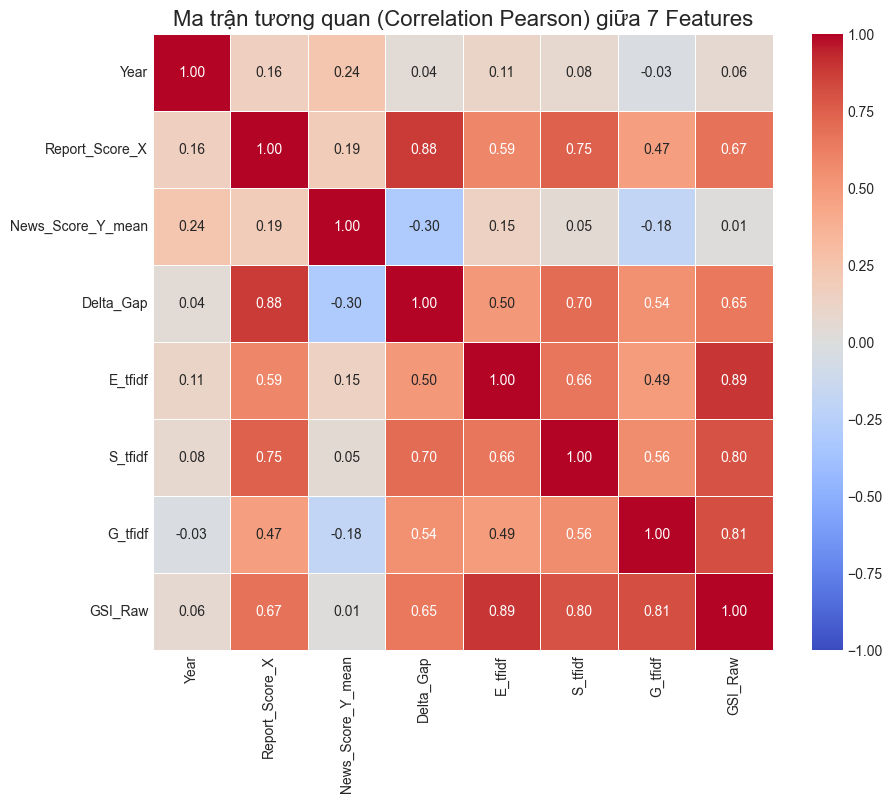

In [4]:
plt.figure(figsize=(10, 8))
# Chọn các cột số để tính tương quan (Bỏ qua cột Bank_Name text)
corr = df.select_dtypes(include=[np.number]).corr()

# Vẽ bản đồ nhiệt tự động
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận tương quan (Correlation Pearson) giữa 7 Features', fontsize=16)
plt.show()

### 3. Phân phối điểm ESG (Boxplot - Biểu đồ hộp)
Đánh giá xem điểm E, S, G điểm nào dao động nhiều nhất và điểm nào phân bổ đồng đều.

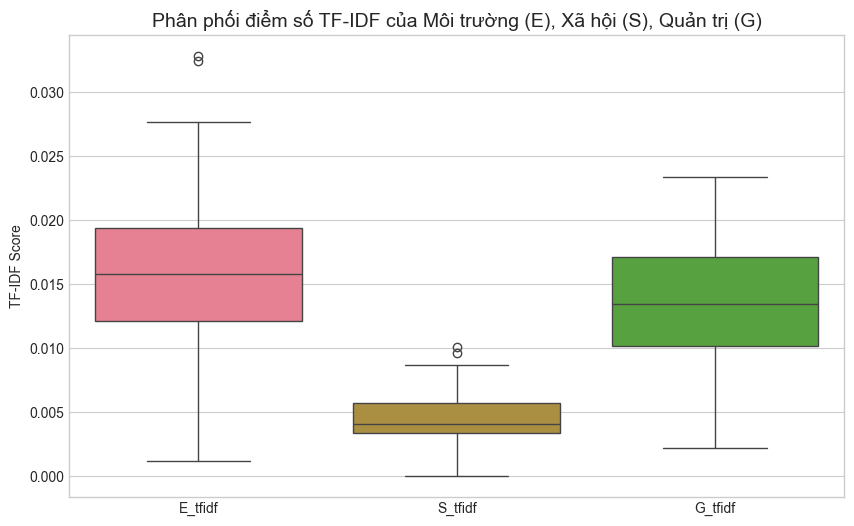

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['E_tfidf', 'S_tfidf', 'G_tfidf']])
plt.title('Phân phối điểm số TF-IDF của Môi trường (E), Xã hội (S), Quản trị (G)', fontsize=14)
plt.ylabel('TF-IDF Score')
plt.show()

### 4. Báo cáo (Report) vs Thực tế (News) 
Gắn trên biểu đồ cột kép sát nhau để so sánh rõ ràng sự khác biệt.

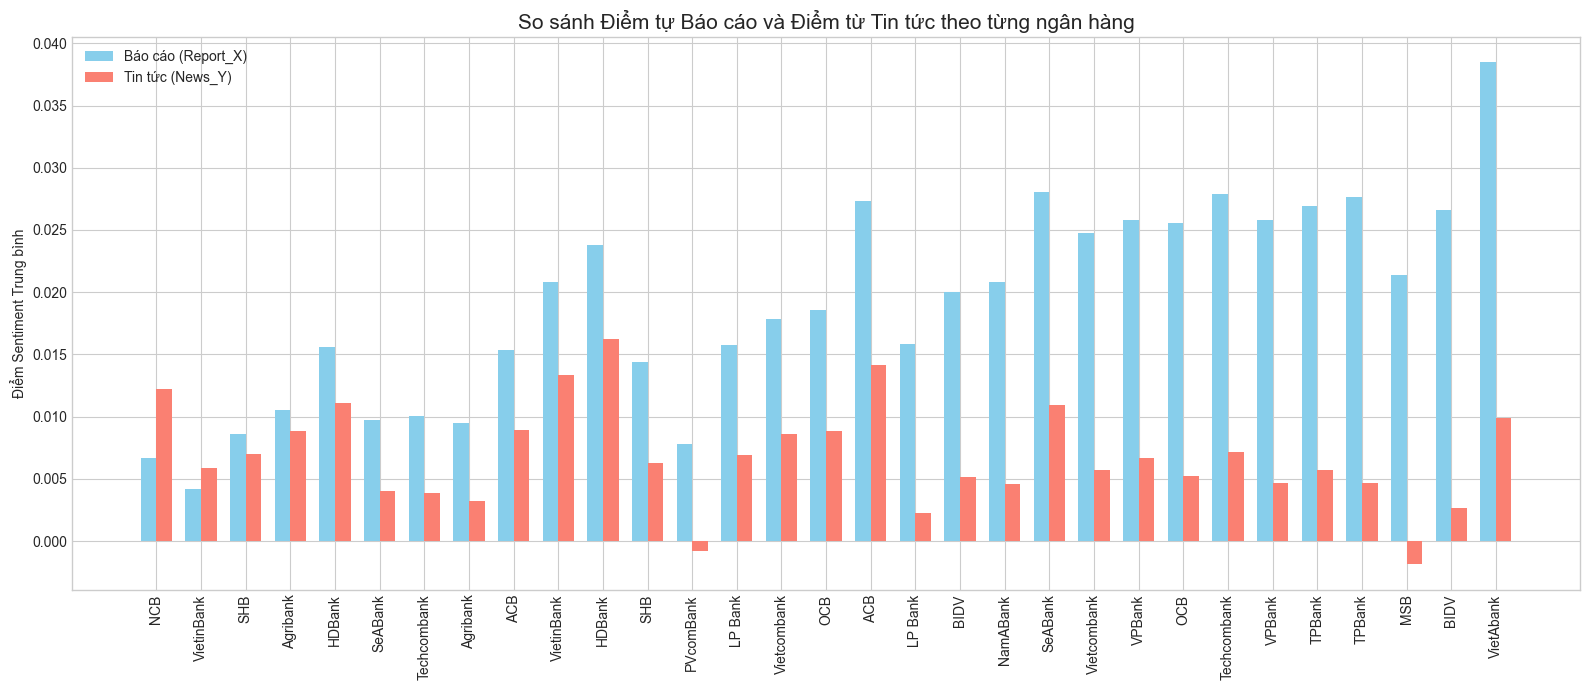

In [6]:
# Sắp xếp ngân hàng theo Delta_Gap để biểu đồ đẹp hơn
df_sorted = df.sort_values('Delta_Gap')

x = np.arange(len(df_sorted['Bank_Name']))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
rects1 = ax.bar(x - width/2, df_sorted['Report_Score_X'], width, label='Báo cáo (Report_X)', color='skyblue')
rects2 = ax.bar(x + width/2, df_sorted['News_Score_Y_mean'], width, label='Tin tức (News_Y)', color='salmon')

ax.set_ylabel('Điểm Sentiment Trung bình')
ax.set_title('So sánh Điểm tự Báo cáo và Điểm từ Tin tức theo từng ngân hàng', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(df_sorted['Bank_Name'], rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

### 5. Delta Gap có tác động tới GSI không? (Scatter Plot)
Xem ngân hàng nói quá (Delta_Gap lớn) thì GSI thực tế nằm ở đâu.

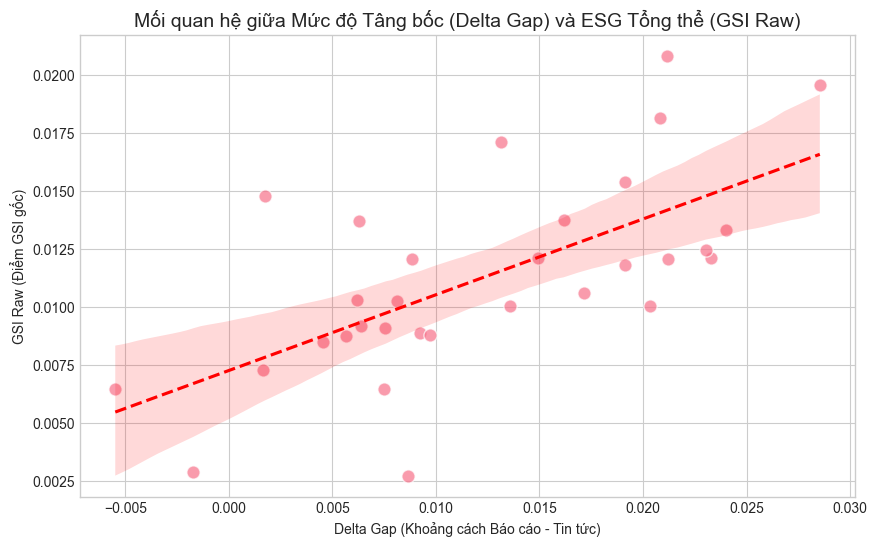

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Delta_Gap', y='GSI_Raw', 
            scatter_kws={'s': 90, 'alpha': 0.7, 'edgecolors':'w'}, 
            line_kws={'color': 'red', 'linestyle':'--'})

plt.title('Mối quan hệ giữa Mức độ Tâng bốc (Delta Gap) và ESG Tổng thể (GSI Raw)', fontsize=14)
plt.xlabel('Delta Gap (Khoảng cách Báo cáo - Tin tức)')
plt.ylabel('GSI Raw (Điểm GSI gốc)')
plt.show()

### 6. Tổng quan phân phối (Pairplot KDE)
Tạo một tổ hợp ma trận scatter kết hợp đường cong phân phối xác suất cho 4 chỉ số quan trọng nhất.

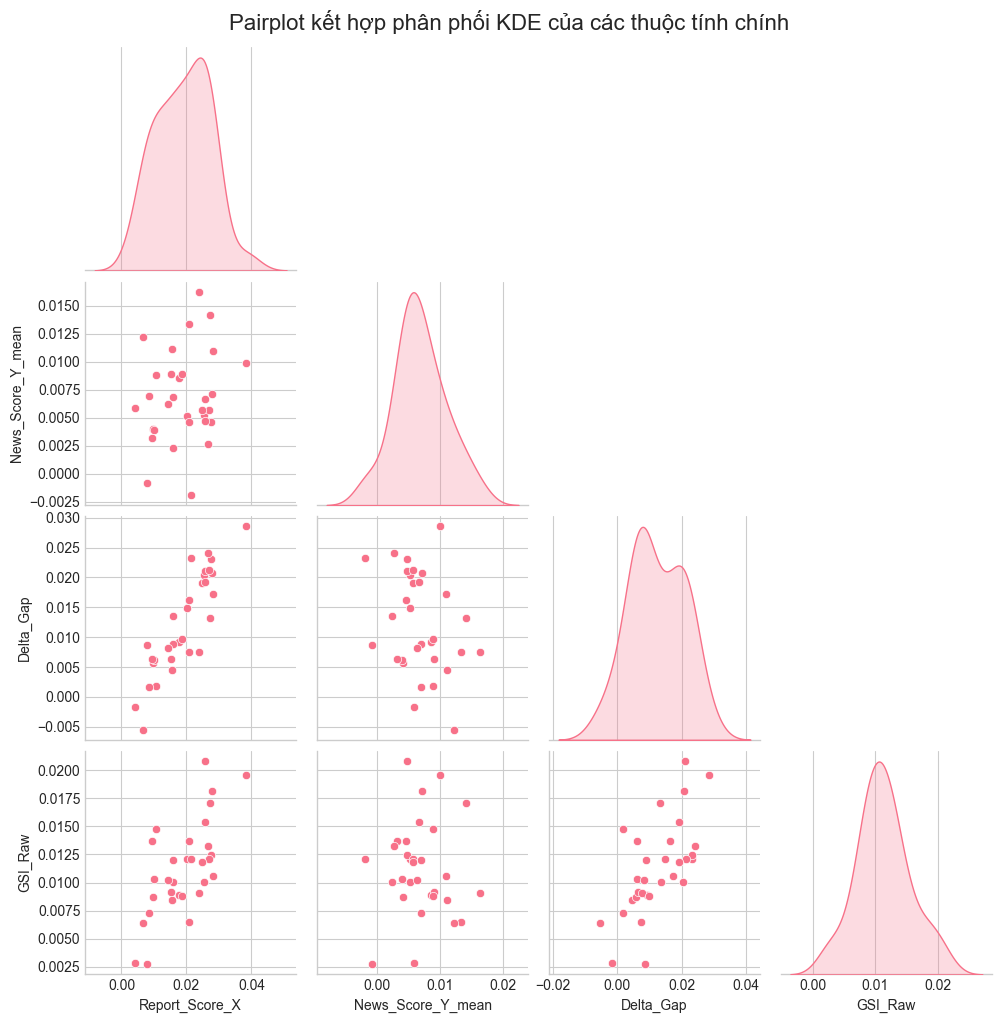

In [8]:
subset_df = df[['Report_Score_X', 'News_Score_Y_mean', 'Delta_Gap', 'GSI_Raw']]

sns.pairplot(subset_df, diag_kind='kde', corner=True, height=2.5)
plt.suptitle('Pairplot kết hợp phân phối KDE của các thuộc tính chính', y=1.02, fontsize=16)
plt.show()

### 7. Chuẩn hóa dữ liệu (Z-Score Normalization)
Vì 7 features (Yếu tố cấu thành lên điểm bền vững và phân hóa khoảng cách) cùng đóng chung 1 vai trò tìm ra nhóm ngân hàng có tính chất "Tẩy xanh", chúng ta bắt buộc phải ép chúng đều có tiếng nói ngang nhau trong hệ quy chiếu thuật toán khoảng cách (ví dụ KNN, K-Means sau này). 

Nếu không chuẩn hóa, sự khác biệt về độ lệch chuẩn (variance bias) giữa các cột (ví dụ: `Report_Score_X` hay `GSI_Raw`) sẽ làm một vài đặc trưng bị mờ nhạt đi. Do đó, cần áp dụng mô hình z-score (`StandardScaler`), kéo trung bình (mean) về `0` và độ lệch chuẩn (std) về `1` cho toàn bộ 7 chiều không gian.

In [9]:
from sklearn.preprocessing import StandardScaler

# Các đặc trưng không gian (Features) để chạy thuật toán tìm Tẩy xanh
features = ['Report_Score_X', 'News_Score_Y_mean', 'Delta_Gap', 'E_tfidf', 'S_tfidf', 'G_tfidf', 'GSI_Raw']

# Khởi tạo mô hình Z-Score (Mean=0, Std=1)
scaler = StandardScaler()

# Tạo bản sao chuẩn hóa
df_scaled = df.copy()

# Fix Z-Score fitting cho toàn bộ 7 chiều
df_scaled[features] = scaler.fit_transform(df[features])

# Trực quan lại dữ liệu thống kê sau khi áp dụng Z-Score
print("Thống kê mô tả 7 Features sau Z-Score (Trung bình = 0, Lệch chuẩn = 1.0):")
display(df_scaled[features].describe().round(4))

# Lưu phiên bản Data Standardized vào một file Excel khác để cắm vào model Machine Learning sau này
output_scaled_path = 'Combined_Features_Scaled.xlsx'
df_scaled.to_excel(output_scaled_path, index=False)
print(f"\n=> Đã xuất dữ liệu chuẩn hóa sang {output_scaled_path} thành công!")

Thống kê mô tả 7 Features sau Z-Score (Trung bình = 0, Lệch chuẩn = 1.0):


,Report_Score_X,News_Score_Y_mean,Delta_Gap,E_tfidf,S_tfidf,G_tfidf,GSI_Raw
count,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000
mean,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000
std,1.0165,1.0165,1.0165,1.0165,1.0165,1.0165,1.0165
min,-1.8545,-2.1692,-2.1438,-2.1963,-1.8845,-1.9792,-2.0503
25%,-0.8239,-0.5522,-0.7175,-0.6125,-0.4937,-0.5162,-0.5832
50%,0.1162,-0.1436,-0.3078,-0.0749,-0.1879,0.0890,-0.1586
75%,0.8330,0.5160,0.9019,0.4500,0.4990,0.7649,0.5348
max,2.4024,2.3436,1.9632,2.4067,2.3239,1.9036,2.2976



=> Đã xuất dữ liệu chuẩn hóa sang Combined_Features_Scaled.xlsx thành công!


### 8. Trực quan hóa sau chuẩn hóa (Post-Normalization EDA)
Vẽ lại Boxplot cho toàn bộ 7 features sau khi đã z-score. 
Lúc này, mọi tính năng đều có trung bình = 0 (đường gạch ngang). Những điểm chấm bi nằm tít trên cao (Z > 2 hoặc Z > 3) phản ánh những tác nhân "Ngoại lệ" (Outliers) - có thể là đối tượng "Tẩy xanh" mạnh nhất.

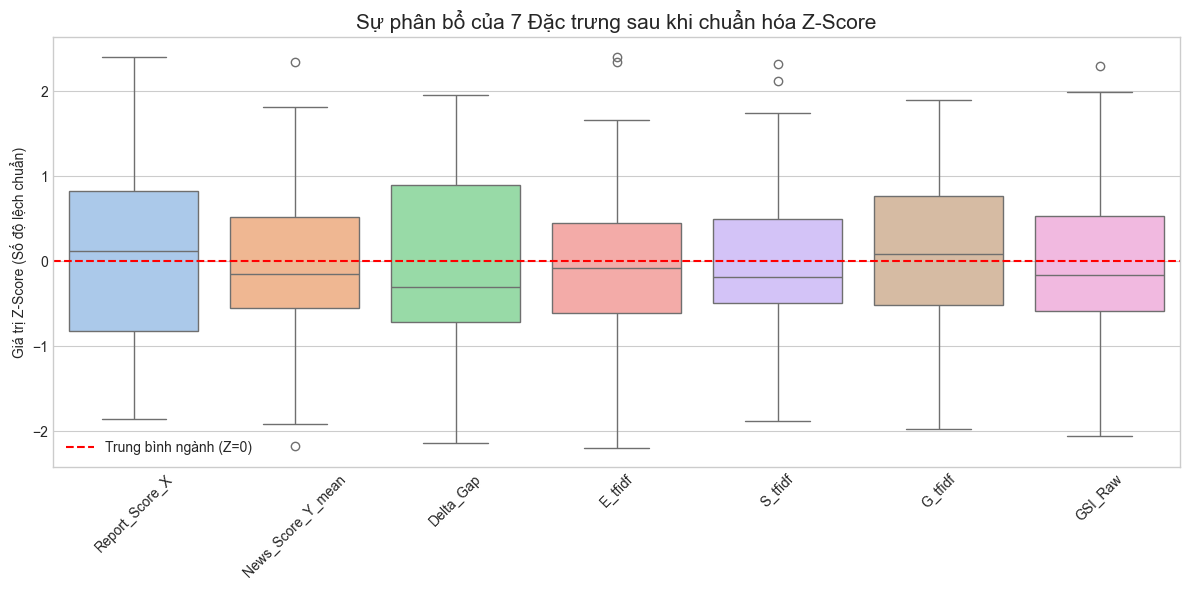

In [10]:
plt.figure(figsize=(12, 6))
# Boxplot toàn bộ 7 tính năng nhưng dùng df_scaled thay vì df
sns.boxplot(data=df_scaled[features], palette="pastel")

# Cạch một đường trung tâm tại mốc 0 (Tức trung bình ngành)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Trung bình ngành (Z=0)')

plt.title('Sự phân bổ của 7 Đặc trưng sau khi chuẩn hóa Z-Score', fontsize=15)
plt.ylabel('Giá trị Z-Score (Số độ lệch chuẩn)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()